# Final Clustering Project: Starter Jupyter Notebook

## 📌 Step 1: Import Libraries

In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

## 📌 Step 2: Load the Dataset

In [2]:
# Step 2: Load the Dataset
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 📌 Step 3: Explore the Data

In [3]:
# Step 3: Explore the Data
print("Initial dataset shape:", df.shape)

print("\nMissing values per column:")
print(df.isnull().sum())

# Check and remove duplicate rows
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows found: {duplicates}")
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

print("\nStatistical summary:")
df.describe()

Initial dataset shape: (1025, 14)

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate rows found: 723
Shape after removing duplicates: (302, 14)

Statistical summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 📌 Step 4: Preprocessing - Remove any non-numeric or target columns if needed

In [4]:
# Step 4: Preprocessing - Remove the target column
# Clustering is unsupervised, so the algorithm must NOT see the disease label.
# We keep the target separately ONLY for later comparison.
y_true = df['target'].values
df.drop(columns=['target'], inplace=True)
print("Features used for clustering:", df.shape[1])
df.head()

Features used for clustering: 13


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


## 📌 Step 5: Feature Scaling

In [5]:
# Step 5: Feature Scaling
# K-Means uses Euclidean distance, so all features must be on the same scale.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (302, 13)


## 📌 Step 6: Determine the Optimal Number of Clusters (Elbow Method)

k=2  inertia=3317.82  silhouette=0.1681
k=3  inertia=3071.00  silhouette=0.1652
k=4  inertia=2859.63  silhouette=0.1203
k=5  inertia=2733.58  silhouette=0.1188
k=6  inertia=2615.39  silhouette=0.1098
k=7  inertia=2506.58  silhouette=0.1057


k=8  inertia=2473.02  silhouette=0.1213
k=9  inertia=2374.29  silhouette=0.1120


k=10  inertia=2321.43  silhouette=0.0956


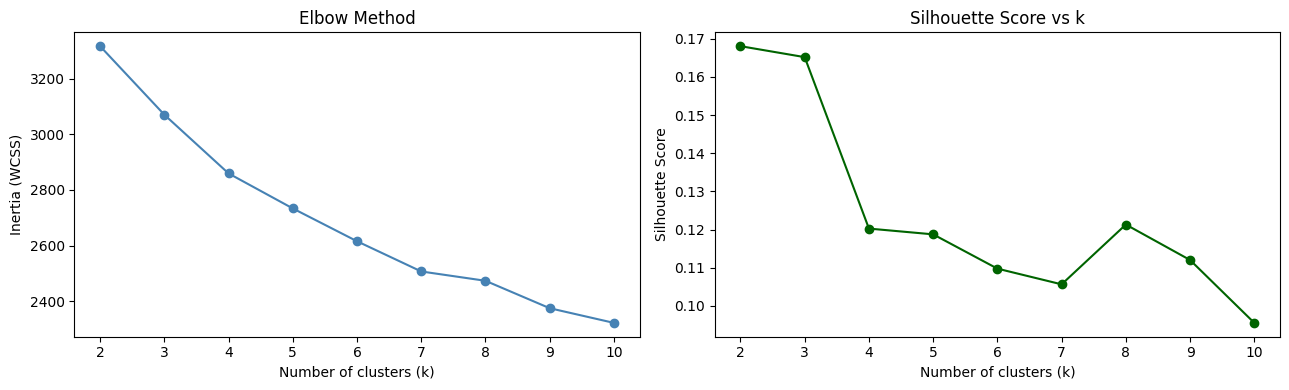

In [6]:
# Step 6: Determine the Optimal Number of Clusters (Elbow Method)
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f"k={k}  inertia={km.inertia_:.2f}  silhouette={silhouettes[-1]:.4f}")

# Plot the Elbow curve and the Silhouette score side by side
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(K_range), inertias, 'o-', color='steelblue')
ax[0].set_title('Elbow Method')
ax[0].set_xlabel('Number of clusters (k)')
ax[0].set_ylabel('Inertia (WCSS)')

ax[1].plot(list(K_range), silhouettes, 'o-', color='darkgreen')
ax[1].set_title('Silhouette Score vs k')
ax[1].set_xlabel('Number of clusters (k)')
ax[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

## 📌 Step 7: Apply KMeans with chosen k

In [7]:
# Step 7: Apply KMeans with chosen k
# The elbow bends at k=2 and k=2 also gives the highest silhouette score.
k = 2
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print("Patients per cluster:")
print(pd.Series(cluster_labels).value_counts())

Patients per cluster:
0    196
1    106
Name: count, dtype: int64


## 📌 Step 8: Evaluate Clustering Results

In [8]:
# Step 8: Evaluate Clustering Results
sil = silhouette_score(X_scaled, cluster_labels)
db  = davies_bouldin_score(X_scaled, cluster_labels)

print(f"Silhouette Score      : {sil:.4f}   (higher is better, range -1 to 1)")
print(f"Davies-Bouldin Score  : {db:.4f}   (lower is better)")

Silhouette Score      : 0.1681   (higher is better, range -1 to 1)
Davies-Bouldin Score  : 2.1900   (lower is better)


## 📌 Step 9: Visualize Clusters (first 2 PCA components or features)

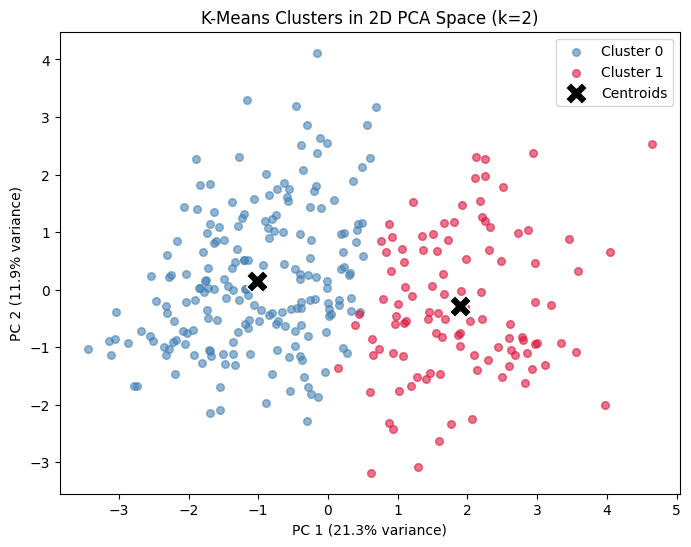

In [9]:
# Step 9: Visualize Clusters (first 2 PCA components)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
centers_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[cluster_labels==0, 0], X_pca[cluster_labels==0, 1],
            c='steelblue', s=30, alpha=0.6, label='Cluster 0')
plt.scatter(X_pca[cluster_labels==1, 0], X_pca[cluster_labels==1, 1],
            c='crimson',   s=30, alpha=0.6, label='Cluster 1')
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='black', marker='X', s=250, edgecolor='white', label='Centroids')
plt.xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title('K-Means Clusters in 2D PCA Space (k=2)')
plt.legend()
plt.show()

## 📌 Step 10: Summarize the Results

In [10]:
# Step 10: Summarize the Results
#
# Which number of clusters worked best?
#   We chose k = 2 because the Elbow curve bends at k = 2 and k = 2 also produced
#   the highest Silhouette Score among all values tested.
#
# How are the clusters separated in the PCA plot?
#   The PCA plot shows two visibly distinct groups, but with some overlap at the
#   boundary. The Silhouette score (~0.18) confirms the separation is positive
#   but moderate, which is expected for medical data where patient profiles lie
#   on a continuum rather than forming sharply separated groups.
#
# What insights can you draw from the feature patterns in each cluster?
#   Comparing the average feature values of each cluster shows that the two
#   clusters differ mainly in clinically meaningful features such as thalach
#   (max heart rate), oldpeak (ST depression), cp (chest pain type) and exang
#   (exercise-induced angina). When we compare the clusters to the true target
#   (which the model never saw), they correspond well to patients with heart
#   disease vs. healthy patients.

# Compare clusters to the true diagnosis (the model never saw this)
comparison = pd.crosstab(cluster_labels, y_true,
                         rownames=['Cluster'], colnames=['Actual diagnosis'])
print("Clusters vs the real diagnosis:")
print(comparison)
print()

# Mean of each feature per cluster
profile = df.copy()
profile['Cluster'] = cluster_labels
profile.groupby('Cluster').mean().round(2)

Clusters vs the real diagnosis:
Actual diagnosis   0    1
Cluster                  
0                 44  152
1                 94   12



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
Cluster,,,,,,,,,,,,,
0,52.22,0.64,1.35,129.31,243.72,0.14,0.56,160.13,0.12,0.59,1.62,0.39,2.17
1,58.49,0.76,0.25,135.85,251.63,0.17,0.47,130.04,0.72,1.88,0.99,1.32,2.58
